# Reddit Data Science Analysis

## Part A. Objective

The objective of this project is to perform an exploratory data analysis (EDA) on
posts from the r/datascience subreddit in order to identify discussion themes,
engagement patterns, and temporal trends within the data science community.

Specifically, this study aims to analyze Reddit post metadata and text to
understand what topics are most frequently discussed, which topics generate the
highest user engagement, and how posting behavior evolves over time.


### Specific Objectives

1. Describe the structure and characteristics of the r/datascience dataset,
   including post frequency, missing values, and basic descriptive statistics.

2. Categorize Reddit posts into meaningful topic groups (e.g., Salary, Career,
   Learning, Projects, AI/LLM) using rule-based keyword matching on post titles.

3. Compare user engagement across different topic categories using post score
   and comment count as engagement metrics.

4. Analyze temporal patterns in subreddit activity by examining posting trends
   over time and by hour of day.

5. Investigate relationships between post characteristics (such as title
   length) and engagement metrics.

6. Extract and analyze common textual patterns in post titles and bodies using
   basic natural language processing techniques, including word frequency analysis.

7. Assess sentiment polarity of post content and evaluate
   how sentiment varies across topic categories.


## Part B. Data Description

### Data Source and Collection

Data was collected using a custom Python script that queries Reddit and stores the results in CSV format.
Each record represents a single Reddit post and includes metadata and textual
content such as post title, author, engagement metrics, and timestamp.

The data covers posts published between November 2025 and January 2026.

### Observation Unit

Each row in the dataset corresponds to one Reddit post submitted to the
r/datascience subreddit.

### Variables Description

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

sns.set_style("darkgrid")
plt.rcParams.update({'font.size': 12})

df = pd.read_csv('data/reddit_datascience.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   url            125 non-null    object
 1   post_id        125 non-null    object
 2   post_title     125 non-null    object
 3   author         125 non-null    object
 4   score          125 non-null    int64 
 5   comment_count  125 non-null    int64 
 6   created_utc    125 non-null    object
 7   body           95 non-null     object
dtypes: int64(2), object(6)
memory usage: 7.9+ KB


[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Variables

| Column Name     | Description |
|-----------------|-------------|
| url             | Link to the Reddit post |
| post_id         | Unique identifier for each Reddit post |
| post_title      | Title of the Reddit post |
| author          | Username of the post author |
| score           | Net upvote score of the post |
| comment_count   | Number of comments on the post |
| created_utc     | Post creation time in UTC |
| body            | Text content of the post |


### Dataset Size and Time Converage

In [346]:
df.shape

(125, 8)

In [347]:
df['created_utc'].min(), df['created_utc'].max()

('2025-10-31 13:11:19+00:00', '2026-01-09 01:16:05+00:00')

The dataset contains 125 Reddit posts and spans a period of approximately three months, from November 2025 to January 2026.

### Missing Values and Data Quality

In [348]:
df.isna().sum()

url               0
post_id           0
post_title        0
author            0
score             0
comment_count     0
created_utc       0
body             30
dtype: int64

Most variables are complete, although some posts contain missing body text.
These missing values are expected, as not all Reddit posts include a text body.

In [349]:
df['author'].unique()

array(['AutoModerator', 'Omega037', 'ThrowRA-11789', 'Daniel-Warfield',
       'bfg2600', 'avourakis', 'ciaoshescu', 'Accomplished-Eye-813',
       'DataAnalystWanabe', 'Careless-Tailor-2317', 'Huge-Leek844',
       'AsparagusKlutzy1817', 'ItzSaf', 'LebrawnJames416', 'guna1o0',
       'ergodym', 'Sudden_Beginning_597', 'BurnerMcBurnersonne',
       'norfkens2', 'redditisthenewblak', 'Mediocre_Common_4126',
       'ChavXO', 'Illustrious-Mind9435', 'Tarneks', 'Throwawayforgainz99',
       'candleflame3', 'DeepAnalyze', 'Alarmed-Reporter-230',
       'Rich-Effect2152', 'ds_contractor', 'dsptl', 'Fig_Towel_379',
       'Trick-Interaction396', 'GirlLunarExplorer', 'EvilGarlicFarts',
       'Thinker_Assignment', 'Ill-Ad-9823', 'petburiraja',
       'Will_Tomos_Edwards', 'MightGuy8Gates', 'Cross_examination',
       'Starktony11', 'LilParkButt', 'a_girl_with_a_dream',
       'AdministrativeRub484', 'BSS_O', 'rsesrsfh', 'Ok_Post_149',
       'Gaston154', 'alpha_centauri9889', 'Intrepid-Self-35

AutoModerator presence (bot in reddit) should be removed later.

In [350]:
df.duplicated().sum()

np.int64(0)

No duplicated rows

### Basic Descriptive Statistics

In [351]:
df[['score', 'comment_count']].describe().round(4)

,score,comment_count
count,125.0000,125.0000
mean,44.1280,25.4160
std,61.8766,24.9913
min,0.0000,1.0000
25%,10.0000,10.0000
50%,26.0000,17.0000
75%,52.0000,34.0000
max,462.0000,130.0000


Post scores and comment counts exhibit a right-skewed distribution, with most posts receiving low engagement and a small number of posts attracting high levels of interaction.

Posting activity is uneven across the observed period, with visible fluctuations in the number of posts per day.

## Part C. Data Cleaning and Preparation

### Initial Data Inspection

Before analysis, the dataset was inspected to identify missing values, inconsistent formats, and irrelevant records.

In [352]:
df.head()

,url,post_id,post_title,author,score,comment_count,created_utc,body
0,https://old.reddit.com/r/datascience/comments/...,t3_1q4co2e,Weekly Entering & Transitioning - Thread 05 Ja...,AutoModerator,1,8,2026-01-05 05:01:38+00:00,Welcome to this week's entering & transitionin...
1,https://old.reddit.com/r/datascience/comments/...,t3_1q0vtzx,[Official] 2025 End of Year Salary Sharing thread,Omega037,112,123,2026-01-01 04:38:20+00:00,This is the official thread for sharing your c...
2,https://old.reddit.com/r/datascience/comments/...,t3_1q7uc1o,End of my DS Road?,ThrowRA-11789,12,3,2026-01-09 01:16:05+00:00,I’m currently a data scientist and entertainin...
3,https://old.reddit.com/r/datascience/comments/...,t3_1q64yb5,Improvable AI - A Breakdown of Graph Based Agents,Daniel-Warfield,12,6,2026-01-07 03:51:12+00:00,For the last few years my job has centered aro...
4,https://old.reddit.com/r/datascience/comments/...,t3_1q5kb9b,Ds Masters never found job in DS,bfg2600,118,106,2026-01-06 14:38:22+00:00,"Hello all, I got my Data Science Masters in Ma..."


In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   url            125 non-null    object
 1   post_id        125 non-null    object
 2   post_title     125 non-null    object
 3   author         125 non-null    object
 4   score          125 non-null    int64 
 5   comment_count  125 non-null    int64 
 6   created_utc    125 non-null    object
 7   body           95 non-null     object
dtypes: int64(2), object(6)
memory usage: 7.9+ KB


### Handling Date and Time Variables 

The `created_utc` variable was converted from string datetime format to a Python datetime object to enable time-based analysis. 

All timestamps are kept in Coordinated Universal Time (UTC).

In [354]:
df['created_utc'] = pd.to_datetime(df['created_utc'])

### Handling Missing Values 

Some posts contain missing body text, which is expected as Reddit allows title-only submissions. These missing values were retained or removed depending on the analysis context.

In [355]:
# Remove post with missing titles or bodies
df = df.dropna(subset=['post_title', 'body'])

### Removing Irrelevant or System Accounts

Posts authored by AutoModerator were removed from the dataset, as they do not represent organic user-generated discussion.

In [356]:
df = df[df['author'] != 'AutoModerator'].reset_index(drop=True)

#### Removing Duplicated Rows

In [357]:
df.duplicated(subset='post_id').sum()

np.int64(0)

No duplicate posts were found based on unique post identifiers.


### Feature Engineering

#### Post Categorization

Posts were categorized into topic groups using rule-based keyword matching on post titles. This categorization enables comparison of engagement across different discussion themes.

In [358]:
# Create a simple category label
def categorize(title):
    t = title.lower().strip()
    
    if any(phrase in t for phrase in [
        "salary", "total comp", "total compensation", "pay", "compensation", 
        "official", "sharing thread", "end of year"
    ]):
        return "Salary"

    if any(phrase in t for phrase in [
        "job", "career", "hiring", "resume", "cv", "interview", "faang", 
        "big tech", "transition", "break into", "entry level", "freelance",
        "contract", "remote", "relocate", "masters", "phd", "degree", "bootcamp"
    ]):
        return "Career"

    if any(phrase in t for phrase in [
        "project", "portfolio", "build", "side project", "dissertation", 
        "capstone", "showcase", "demo", "github", "kaggle", "competition"
    ]):
        return "Project"

    if any(phrase in t for phrase in [
        "advice", "tip", "help", "recommend", "suggest", "can someone",
        "how do i", "how to", "what should i", "is it worth", "should i",
        "anyone have", "looking for", "best way", "what’s the best",
        "am i", "do i need", "why is", "why does", "what are the",
        "tell me", "explain", "clarify", "make sense", "does this",
        "pretend i", "still care", "never found"
    ]):
        return "Advice"

    if any(phrase in t for phrase in [
        "learn", "learning", "tutorial", "course", "book", "mooc", 
        "python", "r", "sql", "pandas", "tensorflow", "pytorch", 
        "machine learning", "deep learning", "statistics", "math",
        "beginner", "roadmap", "study", "practice", "exercise"
    ]):
        return "Learning"

    if any(phrase in t for phrase in [
        "llm", "ai", "genai", "large language model", "agent", "rag", 
        "transformer", "gpt", "chatbot", "copilot", "agentic"
    ]):
        return "AI/LLM"

    return "Other"

df['category'] = df['post_title'].apply(categorize)

    Limitation:
This method relies on title keywords and may misclassify ambiguous posts.


#### Temporal Features

Additional time-based features were extracted from the post timestamp to support temporal analysis.

In [359]:
df['hour'] = df['created_utc'].dt.hour
df['date'] = df['created_utc'].dt.date

#### Text-Based Features 


The length of post titles was computed as a proxy for content verbosity.

In [360]:
df['title_length'] = df["post_title"].str.len()

### Text Normalization

Post text was normalized by converting to lowercase and removing non-alphabetic
characters to support word frequency analysis.

In [361]:
df['clean_body'] = (
    df['body']
    .fillna('')
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
)

### Final Dataset Overview

In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   url            88 non-null     object             
 1   post_id        88 non-null     object             
 2   post_title     88 non-null     object             
 3   author         88 non-null     object             
 4   score          88 non-null     int64              
 5   comment_count  88 non-null     int64              
 6   created_utc    88 non-null     datetime64[ns, UTC]
 7   body           88 non-null     object             
 8   category       88 non-null     object             
 9   hour           88 non-null     int32              
 10  date           88 non-null     object             
 11  title_length   88 non-null     int64              
 12  clean_body     88 non-null     object             
dtypes: datetime64[ns, UTC](1), int32(1), int64(3), objec

After cleaning and preparation, the dataset is ready for exploratory analysis and contains engineered features for temporal, categorical, and textual analysis.

## Part D. Methodology

### Overall Analytical Approach

This study follows an exploratory data analysis (EDA) approach combined with basic natural language processing techniques. EDA is used to summarize, visualize, and understand patterns in Reddit post metadata, while NLP methods are applied to extract insights from textual content.

The analysis focuses on descriptive and comparative methods rather than predictive modeling, as the primary objective is to understand community discussion behavior.


### Engagement Metrics

User engagement is measured using two Reddit-provided metrics:
- **Post Score**: the net number of upvotes a post receives.
- **Comment Count**: the total number of comments on a post.

These metrics capture different aspects of engagement: post score reflects overall approval, while comment count reflects discussion intensity.


### Topic Categorization

Posts were categorized into thematic groups using a rule-based keyword matching approach applied to post titles. Categories include Salary, Career, Learning, Project, Advice, AI/LLM, and Other.

Each title was assigned to a category based on the presence of predefined keywords associated with that topic.

#### Why this method?

This approach was chosen for its simplicity, transparency, and suitability for small datasets. While effective for high-level grouping, this method may misclassify posts with ambiguous or non-descriptive titles.


### Temporal Analysis

Temporal patterns were analyzed by aggregating posts by date and by hour of posting. Datetime features were extracted from post creation timestamps to examine posting frequency trends over time and daily posting behavior.


### Relationship Analysis

Relationships between engagement metrics and post characteristics were examined using scatter plots and Pearson correlation coefficients. Specifically, the relationships between post score and comment count, as well as title length and post score, were analyzed.


### Text Analysis

Basic natural language processing techniques were applied to post titles and bodies to identify common terms and thematic patterns. Text preprocessing included lowercasing, removal of punctuation, and stopword filtering.

Word frequency analysis and word cloud visualizations were used to highlight prominent terms within the dataset and within specific categories.


### Sentiment Analysis

Sentiment polarity of post bodies was measured using the VADER sentiment analysis tool. Each post was assigned a compound sentiment score ranging from −1 (negative) to +1 (positive). Sentiment distributions were then compared across topic categories.

VADER is well-suited for short, informal text commonly found in social media content.



### Tools and Libraries

The analysis was conducted using Python. Key libraries include:
- pandas and NumPy for data manipulation
- matplotlib and seaborn for visualization
- nltk for text processing and sentiment analysis


## Part E. Results and Insights

### Overall Dataset Overview
**Question**: What is the general engagement level of posts in r/datascience?

In [363]:
df[['score', 'comment_count']].describe().round(4)

,score,comment_count
count,88.0000,88.0000
mean,43.2841,26.4659
std,58.8208,26.4332
min,0.0000,1.0000
25%,12.0000,8.7500
50%,30.5000,16.5000
75%,52.7500,34.2500
max,462.0000,130.0000


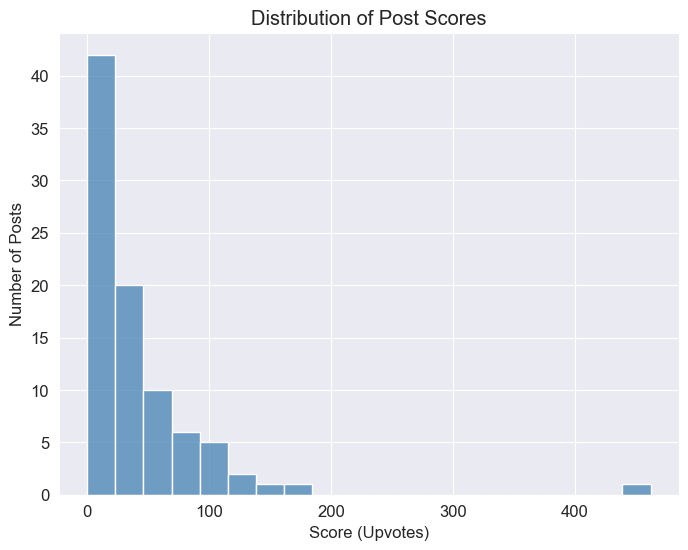

In [364]:
plt.figure(figsize=(8,6))
sns.histplot(df["score"], bins=20, color="steelblue", kde=False)

plt.xlabel("Score (Upvotes)")
plt.ylabel("Number of Posts")
plt.title("Distribution of Post Scores")
plt.show()

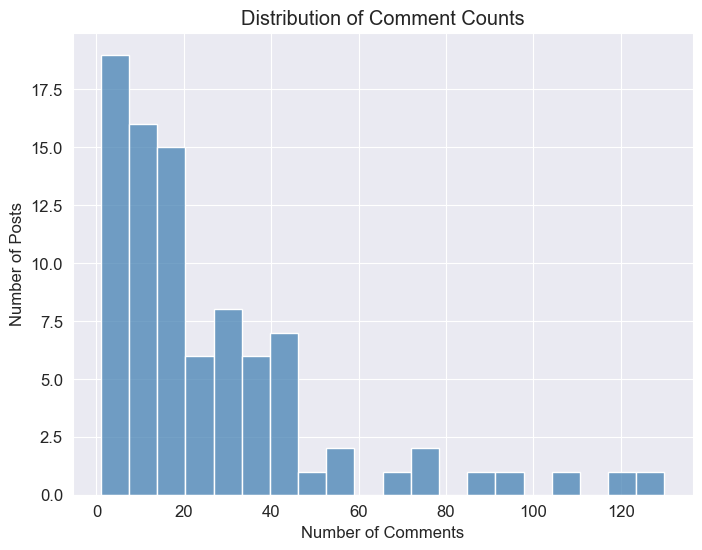

In [365]:
plt.figure(figsize=(8,6))
sns.histplot(df["comment_count"], bins=20, color="steelblue", kde=False)

plt.xlabel("Number of Comments")
plt.ylabel("Number of Posts")
plt.title("Distribution of Comment Counts")
plt.show()

**Insight**: Both post score and comment count show right-skewed distributions, indicating that most posts receive relatively low engagement while a small number of posts attract disproportionately high interaction. This pattern is typical of online community platforms such as Reddit.

### Distribution of Post Topics
**Question**: What topics are most frequently discussed in r/datascience?

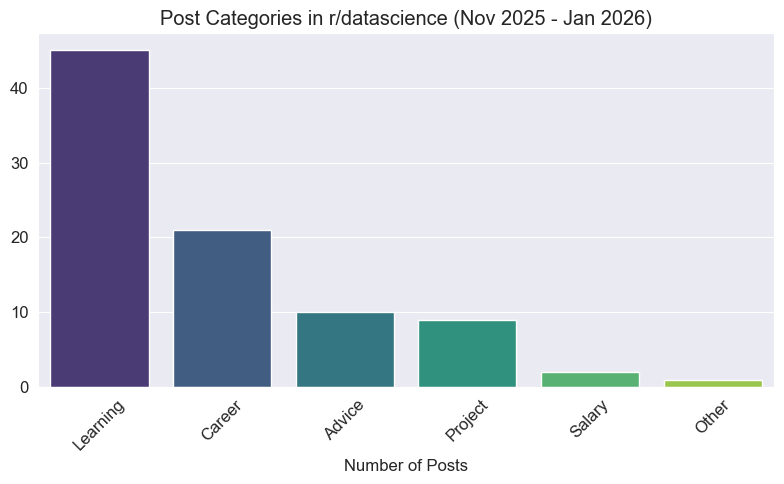

In [ ]:
category_counts = df['category'].value_counts()
# print(category_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis'
)

plt.title("Post Categories in r/datascience (Nov 2025 - Jan 2026)")
plt.xlabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Insight**: Learning-related posts are the most frequent in r/datascience, indicating that the subreddit is primarily used for skill development and knowledge seeking. Career-related posts are the second most common, while salary and project posts appear far less frequently during the observed period.

### Engagement by Topic Category
**Question**: Which topics generate the highest engagement?

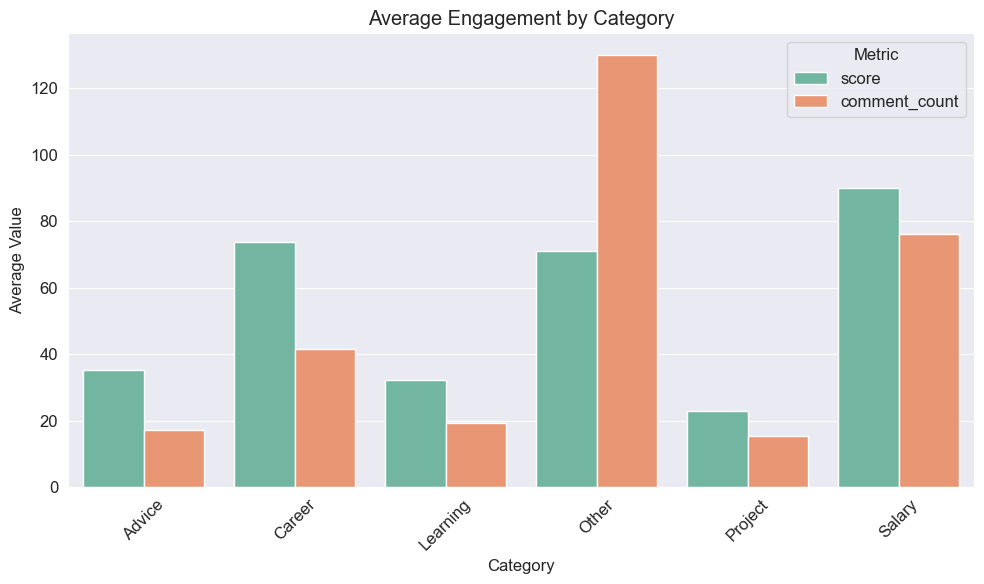

In [ ]:
# Calculate average engagement by category
engagement = (
    df.groupby('category')[['score', 'comment_count']]
    .mean()
    .reset_index()
)

# Reshape data for seaborn
engagement_melted = engagement.melt(
    id_vars='category',
    value_vars=['score', 'comment_count'],
    var_name='Metric',
    value_name='Average Value'
)

plt.figure(figsize=(10, 6))
sns.barplot(data=engagement_melted, x='category', y='Average Value', hue='Metric', palette = "Set2"
)

plt.title("Average Engagement by Category")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Insight**: Posts categorized as Other receive the highest average comment counts, suggesting that unconventional or broadly framed topics often spark extensive discussion. Salary and career-related posts also show high engagement, while learning and project posts tend to generate lower interaction despite their higher frequency, suggesting they appeal to a narrower audience.

### Temporal Trends in Posting Activity
**Question**: How does posting activity change over time?

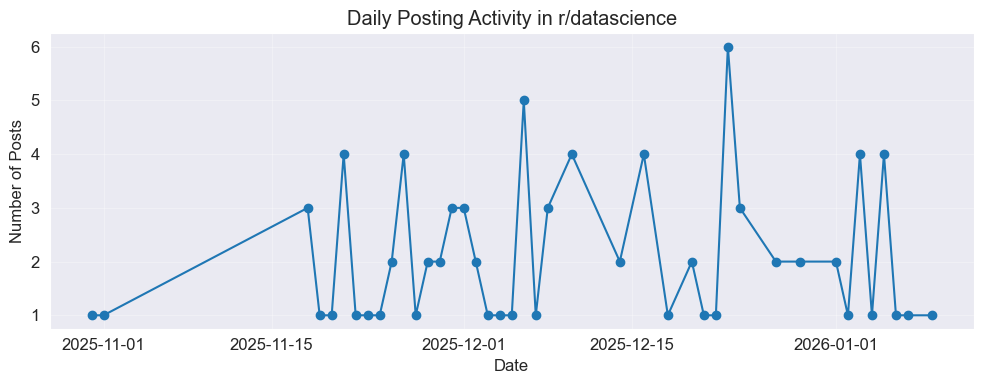

In [368]:
# Ensure date is datetime (even if it's stored as string)
df['date'] = pd.to_datetime(df['date'])

daily_posts = df.groupby('date').size()

plt.figure(figsize=(10,4))
plt.plot(daily_posts.index, daily_posts.values, marker='o')
plt.title('Daily Posting Activity in r/datascience')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Daily posting activity is irregular, with most days containing one to two posts and occasional short spikes of higher activity. This suggests that r/datascience discussions occur steadily rather than in sustained daily bursts.

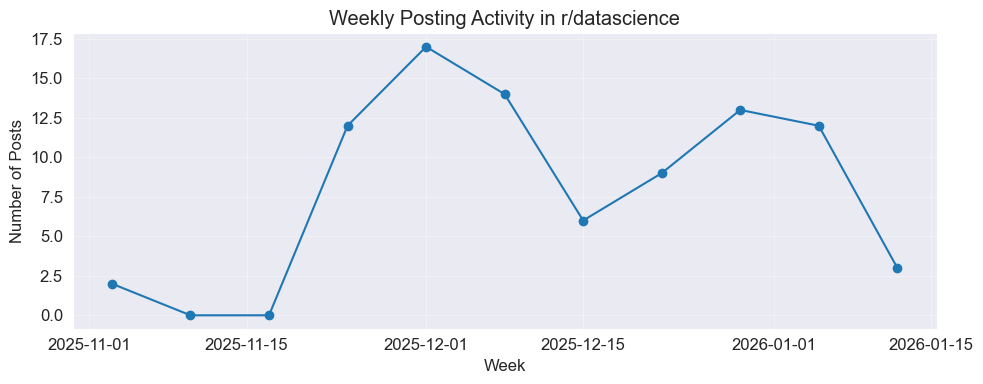

In [ ]:
weekly_posts = daily_posts.resample('W-MON').sum()

plt.figure(figsize=(10,4))
plt.plot(weekly_posts.index, weekly_posts.values, marker='o')
plt.title('Weekly Posting Activity in r/datascience')
plt.xlabel('Week')
plt.ylabel('Number of Posts')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Weekly activity shows clearer variation than daily data, with posting volume increasing toward late November and early December before declining in mid-December and early January. This pattern suggests periodic engagement rather than consistent growth over time.

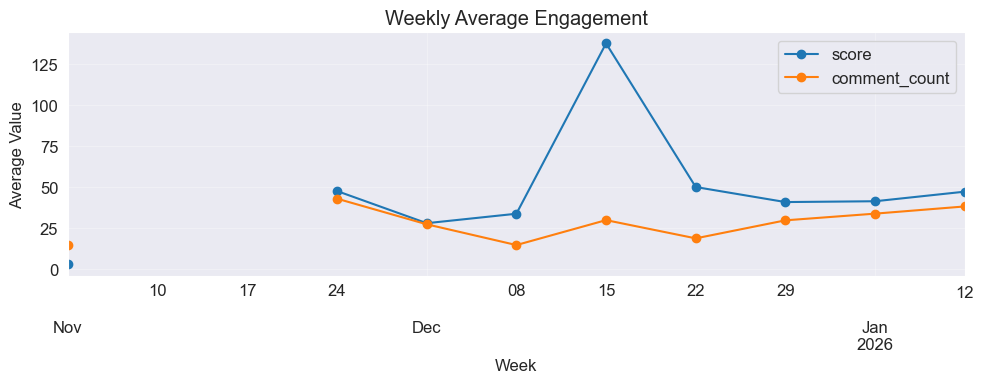

In [370]:
weekly_engagement = (
    df.groupby('date')[['score', 'comment_count']]
      .mean()
      .resample('W-MON')
      .mean()
)

weekly_engagement.plot(figsize=(10,4), marker='o')
plt.title('Weekly Average Engagement')
plt.xlabel('Week')
plt.ylabel('Average Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Average engagement fluctuates substantially across weeks, with a pronounced spike in post score around mid-December despite a moderate number of posts. This indicates that high engagement is driven by a small number of highly impactful posts rather than overall posting volume.

**Insight**: Posting activity in r/datascience remains relatively low and uneven on a daily basis, with most days seeing only one to two posts and occasional short-lived spikes. When aggregated weekly, clearer patterns emerge, showing increased activity in late November and early December followed by a decline toward mid-December and early January. Overall, the subreddit exhibits periodic fluctuations in activity rather than a sustained upward or downward trend over the observed period.

### Hour-of-Day Posting Behavior
**Question**: When are users most active?

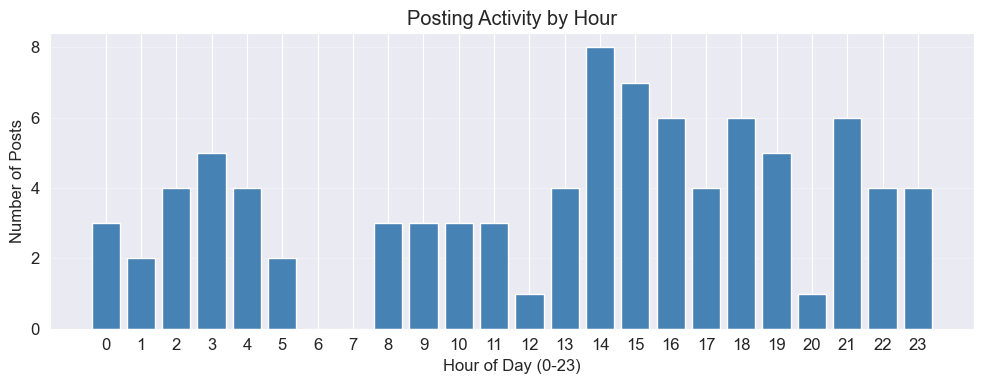

In [ ]:
hour_counts = df['hour'].value_counts().reindex(range(24), fill_value=0).sort_index()

plt.figure(figsize=(10,4))
plt.bar(hour_counts.index, hour_counts.values, color='steelblue')
plt.title('Posting Activity by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Posts')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


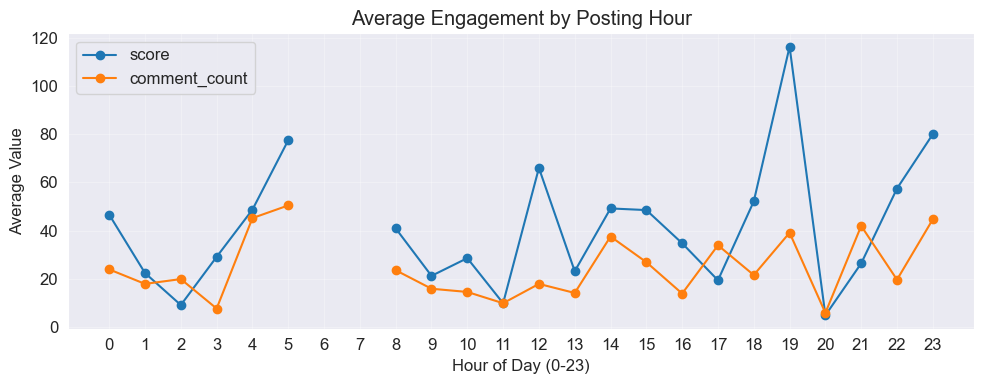

In [372]:
hourly_eng = (
    df.groupby('hour')[['score', 'comment_count']]
      .mean()
      .reindex(range(24))
)

hourly_eng.plot(figsize=(10,4), marker='o')
plt.title('Average Engagement by Posting Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Value')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Posting activity is highest during mid-day to early evening hours (approximately 13:00–19:00 UTC), indicating peak user activity during this period. While fewer posts are submitted late at night and early morning, posts made during certain evening hours show higher average engagement, suggesting that posting time may influence visibility and interaction.

### Relationship Between Engagement Metrics
**Question**: Are posts with more upvotes also more likely to generate discussion?

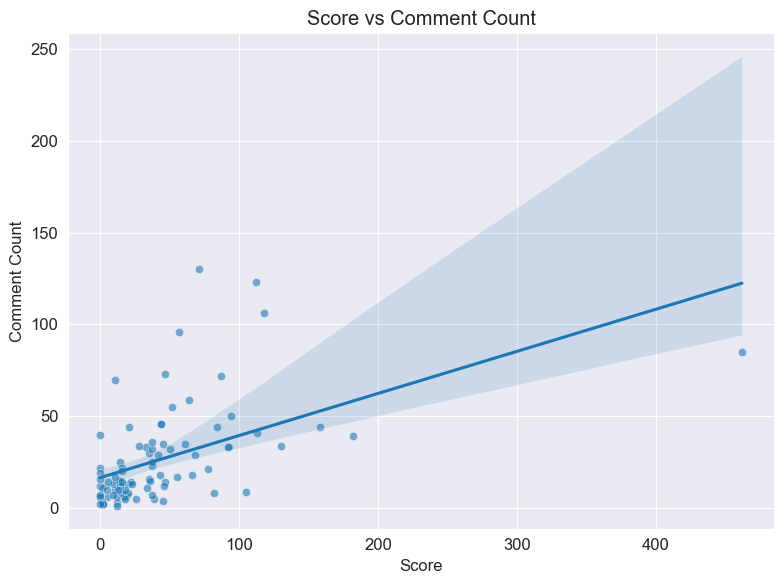

Correlation (score vs comment_count): 0.5101852286346809


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="score", y="comment_count", alpha=0.6)
sns.regplot(data=df, x="score", y="comment_count", scatter=False)

plt.xlabel("Score")
plt.ylabel("Comment Count")
plt.title("Score vs Comment Count")
plt.tight_layout()
plt.show()

corr = df[["score", "comment_count"]].corr().iloc[0,1]
print("Correlation (score vs comment_count):", corr)


**Insight**: The scatter plot shows a positive association between score and comment count: posts that receive more upvotes generally tend to attract more comments. However, the spread is wide, indicating that high-scoring posts do not always generate many comments and some posts can spark discussion without receiving very high scores. Overall, engagement appears related but not perfectly aligned across the two metrics.

### Title Length and Engagement
**Question**: Does title length influence engagement?

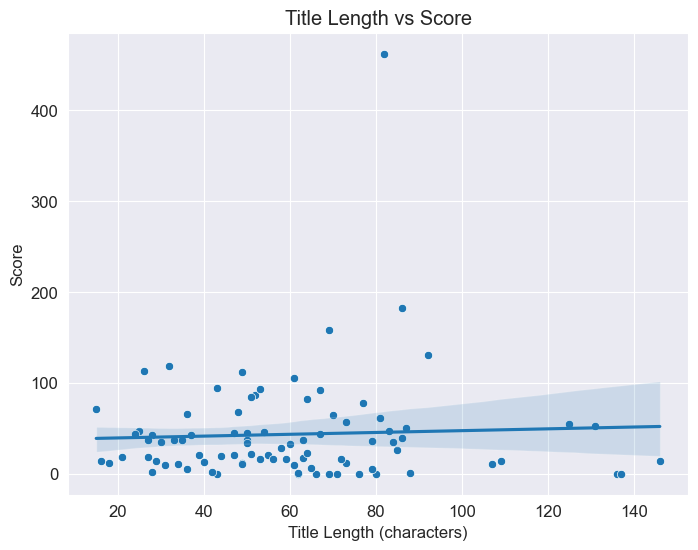

Correlation (score vs title_length): 0.04764949363556268


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="title_length", y="score")
sns.regplot(data=df, x="title_length", y="score", scatter=False)

plt.xlabel("Title Length (characters)")
plt.ylabel("Score")
plt.title("Title Length vs Score")
plt.show()

corr = df[['title_length', 'score']].corr().iloc[0,1]
print(f"Correlation (score vs title_length): {corr}")


**Insight**: The scatter plot shows no clear relationship between title length and post score, indicating that longer titles do not consistently lead to higher engagement. This suggests that the relevance and substance of the post matter more than title verbosity in attracting upvotes.

### Author Contribution Patterns
**Question**: Is posting activity evenly distributed among users?

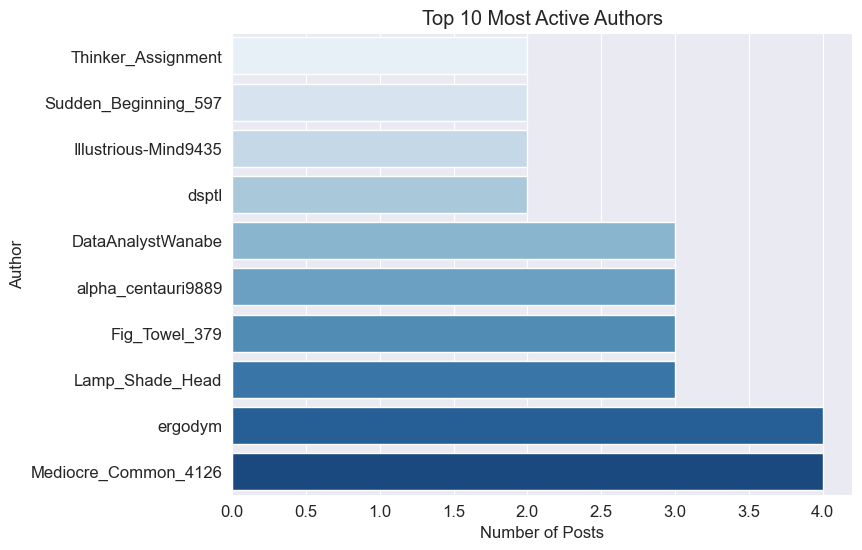

In [375]:
top_authors = df["author"].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='Blues_r', orient='h')

plt.xlabel("Number of Posts")
plt.ylabel("Author")
plt.title("Top 10 Most Active Authors")
plt.gca().invert_yaxis()  # keep highest at top
plt.show()

**Insight**: A small number of users contribute a disproportionately large share of posts, indicating that content creation in r/datascience is driven by a limited group of highly active contributors.

### Textual Patterns in Posts
**Question**: What themes appear most frequently in post titles and bodies?

In [376]:
# Build one stopword set
stop_words = set(stopwords.words("english"))
stop_words |= set(STOPWORDS)  # add wordcloud stopwords too

custom_stopwords = {
    "datascience", "data", "science", "thread", "official", "discussion",
    "reddit", "post", "posts", "title", "subreddit", "career", "projects",
    "self", "amp", "https", "co", "www", "com"
}
stop_words |= custom_stopwords

In [377]:
# Tokenize + filter 
titles = df["post_title"].dropna().astype(str).str.lower()
tokens = re.findall(r"\b[a-z]{3,}\b", " ".join(titles))
filtered = [t for t in tokens if t not in stop_words]

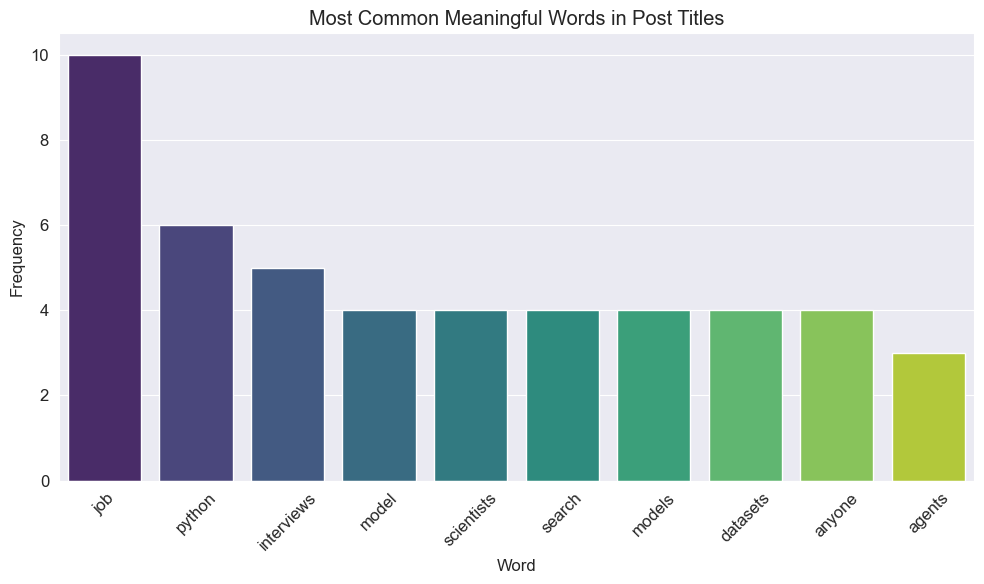

In [ ]:
# Top words bar chart
common_words = Counter(filtered).most_common(10)
words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10,6))
sns.barplot(data=words_df, x="Word", y="Frequency", palette="viridis")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Most Common Meaningful Words in Post Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


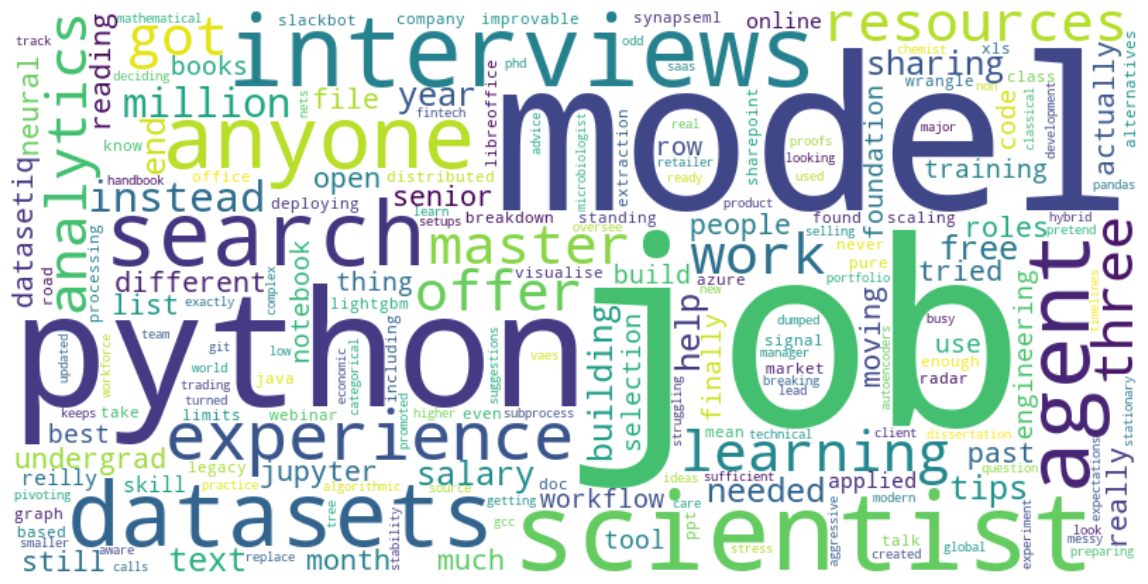

In [ ]:
# Wordcloud
wc_text = " ".join(filtered)  # use the already-filtered tokens
wordcloud = WordCloud(
    width=800, height=400,
    background_color="white",
    collocations=False
).generate(wc_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()


**Insight**: The most frequent keywords in post titles include job, python, and interviews, highlighting a strong focus on employment, technical skills, and hiring processes within r/datascience. The word cloud further reinforces this pattern, with prominent terms related to models, datasets, and agents, indicating that practical tools and applied data science topics are commonly discussed alongside career-oriented concerns.

In [380]:
def top_words_for_category(cat, n=10):
    subset = df.loc[df["category"] == cat, "post_title"].dropna().astype(str).str.lower()
    toks = re.findall(r"\b[a-z]{3,}\b", " ".join(subset))
    toks = [t for t in toks if t not in stop_words]
    return Counter(toks).most_common(n)

top_words_for_category("Salary", 10)

[('salary', 2),
 ('end', 1),
 ('year', 1),
 ('sharing', 1),
 ('deciding', 1),
 ('offer', 1),
 ('higher', 1),
 ('stability', 1)]

**Insight**: Keywords in salary-related posts are centered on compensation evaluation and decision-making, with salary and offer appearing most frequently. Additional terms such as stability, higher, and year suggest that these discussions often focus on long-term financial considerations rather than short-term pay alone.

### Sentiment Analysis Results
**Question**: How does sentiment vary across post categories?

In [381]:
# Import and initialize VADER
from nltk.sentiment import SentimentIntensityAnalyzer

# Download once if not already installed
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mac/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [382]:
# Combine body and title to avoid empty text
df['sentiment_text'] = df['body'].fillna('')
df.loc[df['sentiment_text'].str.strip() == '', 'sentiment_text'] = df['post_title']

In [383]:
# Compute sentiment score
df['sentiment'] = df['sentiment_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [384]:
# Inspect sentiment distribution (sanity check)
df['sentiment'].describe()

count    88.000000
mean      0.568289
std       0.521430
min      -0.986100
25%       0.411575
50%       0.810900
75%       0.931500
max       0.999900
Name: sentiment, dtype: float64

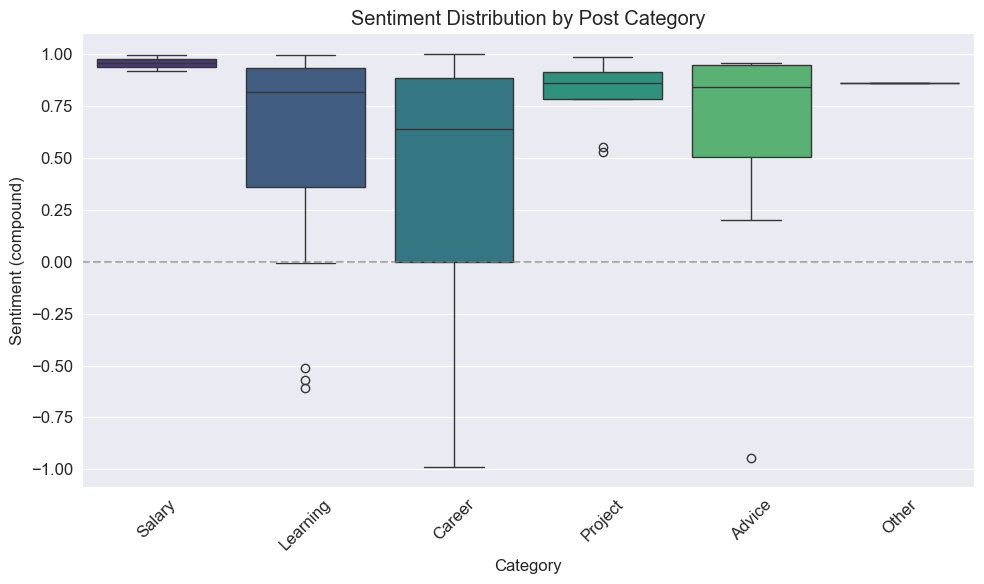

In [ ]:
# Compare sentiment across categories (MAIN RESULT)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='category', y='sentiment', hue='category', palette='viridis')
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('Category')
plt.ylabel('Sentiment (compound)')
plt.title('Sentiment Distribution by Post Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [386]:
# Average sentiment per category
sentiment_by_cat = (
    df.groupby('category')['sentiment']
      .mean()
      .sort_values(ascending=False)
)
print(sentiment_by_cat)

category
Salary      0.958550
Other       0.862500
Project     0.809867
Learning    0.595531
Advice      0.580400
Career      0.349433
Name: sentiment, dtype: float64


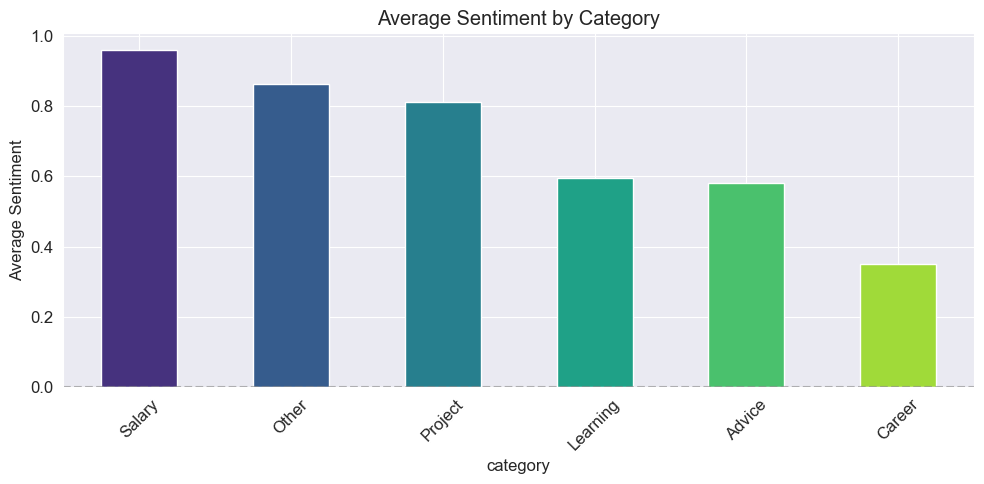

In [ ]:
plt.figure(figsize=(10,5))
sentiment_by_cat.plot(kind='bar', color=sns.color_palette('viridis', len(sentiment_by_cat)))
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.ylabel('Average Sentiment')
plt.title('Average Sentiment by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight**: Overall sentiment across r/datascience posts is predominantly positive, with a median sentiment above zero and a mean compound score of approximately 0.57. Salary-related posts exhibit the highest and most consistently positive sentiment, while career-related posts show the widest variability, including the most negative values. Learning and advice posts tend to cluster around moderately positive sentiment, suggesting generally constructive and supportive discussions.

    Limitation:
Sentiment scores are generated using a rule-based model (VADER) and may not fully capture sarcasm or contextual nuance in Reddit discussions

## Part F. Discussion

This exploratory analysis suggests that r/datascience is primarily used as a learning-oriented community, with learning-related posts appearing most frequently. However, engagement patterns indicate that career and salary discussions generate disproportionately higher interaction, implying that topics involving personal decision-making and experience resonate more strongly with users than purely informational content.

Temporal analysis shows that posting activity varies over time without a clear long-term trend, and high engagement is driven by a small number of impactful posts rather than posting volume alone. Posting time also appears to influence interaction, with higher activity occurring during mid-day to early evening hours (UTC).

Textual and sentiment analyses further support these findings. Common keywords emphasize employment and technical skills, while sentiment results indicate an overall positive tone across posts. Salary-related discussions tend to be consistently positive, whereas career-related posts show greater sentiment variability, reflecting mixed personal experiences.

Overall, the results highlight the dual role of r/datascience as both a learning resource and a forum for career-related discussion. These findings are exploratory in nature and subject to limitations such as a small sample size, rule-based topic categorization, and lexicon-based sentiment analysis.

## Part G. Conclusion & Future Work

This exploratory analysis examined posting behavior, engagement patterns, and textual characteristics of posts in the r/datascience subreddit. The results show that while learning-related posts are the most common, career and salary discussions generate higher engagement and stronger emotional responses. Temporal and hourly analyses suggest that interaction is driven more by post relevance than by posting frequency, and text-based analyses highlight the prominence of employment and technical skill themes.

Future work could extend this analysis by collecting data over a longer time period, applying machine learning–based topic modeling instead of rule-based categorization, and analyzing comment-level data to better understand discussion dynamics. Additionally, more advanced sentiment models could be used to capture nuance such as sarcasm and context in Reddit conversations.